In [455]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2, norm, chisquare
from statsmodels.sandbox.stats.runs import runstest_1samp


# Stochastic Simulation

## DAY 1 

### Exercise 1

#### (a)

In [456]:
# Implementation of linear congruential generator
def LCG(x0, a, c, M, iter): 
    """
    Generate random numbers using a linear congrential generator
    Input: 
        x0: Initial value 
        a: Multiplier 
        c: Increment 
        M: Modulus 
        Iter: How many number iterations

    Output: A list of random number of length iter + 1.      
    """

    # Set initial value  
    x = x0 
    Numbers = [x/M]

    for i in range(iter):
        x = (a*x + c) % M 
        U = x/M 
        Numbers.append(U)
    return Numbers

In [457]:
# Test 1, values as of slides to check if function works correctly
x0 = 3 
M = 16 
a = 5 
c = 1
iter = 16
LCG(x0, a, c, M, iter)

[0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875]

In [458]:
# # Test 2, BAD random numbers 
x0 = 3 
M = 16 
a = 5 
c = 1
iter = 10000 
RN = LCG(x0, a, c, M, iter)
RN

[0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 

(array([1250.,  625., 1251.,  625., 1250.,  625., 1250.,  625., 1250.,
        1250.]),
 array([0.     , 0.09375, 0.1875 , 0.28125, 0.375  , 0.46875, 0.5625 ,
        0.65625, 0.75   , 0.84375, 0.9375 ]),
 <BarContainer object of 10 artists>)

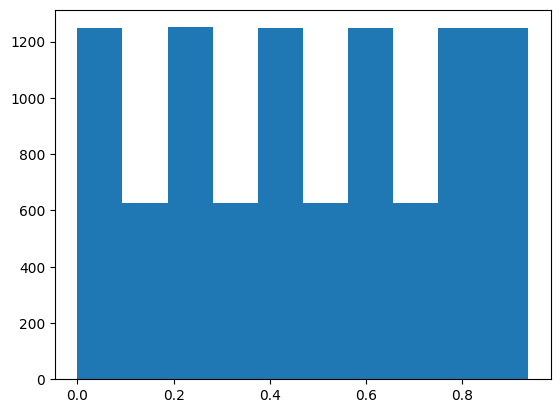

In [459]:
# Histogram plot with 10 bins 

plt.hist(RN,10)

#### (b)

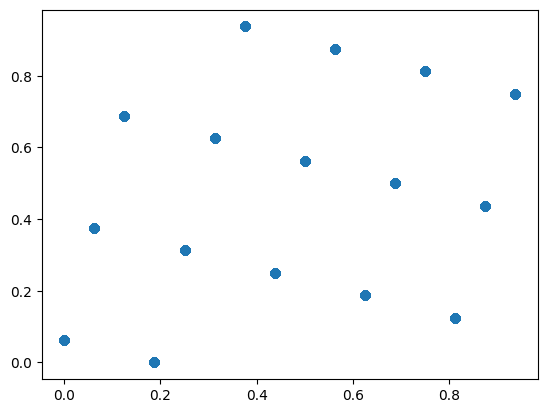

In [460]:
# Scatterplot 

plt.scatter(RN[:-1], RN[1:])

In [461]:
# Define function to do a Chi-squared test 

def T_chi_square(n_observed, n_expected, m): 
    """
    Do a chi_square test
    Input: 
        n_observed: Array with the number of observed numbers at each bin 
        n_expected: The expected number of numbers at each bin given the expected distribution 
        m: The number of estimated parameters 
    
    Output: The p_value for hypothesis test 
    """
    
    # Number of classes 
    n_classes = len(n_observed)

    # Compute the test statistic 
    T = np.sum((n_observed - n_expected)**2/n_expected)


    # Degrees of freedom
    df = n_classes - 1 - m

    # Compute p-value 
    p_value = chi2.sf(T,df)
    return p_value

In [462]:
# Chi-squared test with 10 bins

bins = 10
N = len(RN)
n_observed,_ = np.histogram(RN, bins)
n_expected = np.ones(bins) * (N/bins) #Uniform distribution
m = 0 

T_chi_square(n_observed, n_expected, m) #Small p-value, very unlikely that derivation so large if the data followed a uniform distribution 

np.float64(4.193876173735931e-196)

In [463]:
def ecdf(x,obs): 
    """
    Compute the expected distrubution
    Input: 
    """

    obs = np.array(obs)

    ecdf = np.sum(obs <= x)/len(obs)
    return ecdf

def uniform_cdf(x, a=0, b=1):
    if x < a:
        return 0.0
    elif x > b:
        return 1.0
    else:
        return (x - a) / (b - a)

def Kolmogorov_Smirnov(obs,m): 
    x = np.linspace(0,1,m)
    F_n = []
    F = []
    for val in x:
        F_n.append(ecdf(val, obs))
        F.append(uniform_cdf(val))
    D_n = np.max(abs(np.array(F_n)- np.array(F)))

    return D_n


In [464]:
m = 100
D_n = Kolmogorov_Smirnov(RN, m)
D_n

np.float64(0.062493750624937505)

In [465]:
# Adjusted test statistic 

n = len(RN)

(np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))*D_n # Not good result see 16 

np.float64(6.257255513199329)

In [466]:
# Wald-Wolfowitz run test

def Wald_Wolfowitz(obs):
    median = np.median(obs)
    above_below = []
    for x in obs:
        if x > median:
            above_below.append(1)
        if x <= median: 
            above_below.append(0)
    
    n1 = np.sum(above_below)
    n2 = len(above_below) - n1 
    runs = 1 
    for i in range(1,len(above_below)):
        if above_below[i] != above_below[i-1]:
            runs += 1
    
    T = runs 
 

    mean = 2*n1*n2/(n1 + n2) +1 
    var = 2*(n1*n2*(2*n1*n2 -n1 - n2)/( (n1+n2)**2*(n1 + n2 -1)))
    z = (T - mean)/np.sqrt(var)
    
    p_values = 2*norm.sf(abs(z))
    return p_values
    


In [467]:
# run test 1
Wald_Wolfowitz(RN)

np.float64(4.759054458520932e-138)

In [468]:
def knuth(obs):
    obs = np.array(obs)
    n = len(obs)

    # --- Step 1: compute increasing runs ---
    lengths = []
    current_len = 1

    for i in range(1, n):
        if obs[i] > obs[i - 1]:
            current_len += 1
        else:
            lengths.append(current_len)
            current_len = 1

    

    R = np.zeros(6)
    for r in lengths:
        if r <= 5: 
            R[r-1] += 1 
        else: 
            R[5] += 1 
    
    A = np.array([
    [4529.4,  9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
    ])

    B = np.array([
    [1/6],
    [5/24],
    [11/120],
    [19/720],
    [29/5040],
    [1/840]
    ])

    
    d = R - n*B.flatten()
    Z = (d.T @ A @ d) / (n - 6)
    


    
    df = 6
    p_value = chi2.sf(Z,df)
  
    return p_value
            
    

In [469]:
knuth(RN)

np.float64(1.4733787998841428e-238)

In [470]:
def correlation_coef(obs,h):
    obs = np.array(RN)
    n= len(obs)
    c = np.sum(obs[:-h] * obs[h:]) / (n - h)

    mean = 0.25
    var = 7/(144*n)
    z = (c - mean)/np.sqrt(var)
    
    p_values = 2*norm.sf(abs(z))
    return p_values

In [471]:
correlation_coef(RN,1)

np.float64(0.00039471242218985114)

In [472]:
correlation_coef(RN,3)

np.float64(1.1720063046768725e-135)

#### (c)

In [473]:
""" 
# GOOD example 
x0 = 3 
M = 2**32 
a = 1203515245
c = 12345
iter = 10000 
RN = LCG(x0, a, c, M, iter)
"""

' \n# GOOD example \nx0 = 3 \nM = 2**32 \na = 1203515245\nc = 12345\niter = 10000 \nRN = LCG(x0, a, c, M, iter)\n'

### Exercise 2 

In [474]:
RN_sys = np.random.rand(10000)


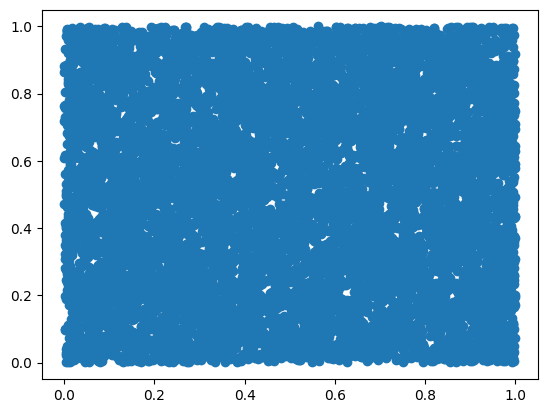

In [475]:
# Scatterplot 

plt.scatter(RN_sys[:-1], RN_sys[1:])

In [476]:
# Chi_square
bins = 10
N = len(RN_sys)
n_observed,_ = np.histogram(RN_sys, bins)
n_expected = np.ones(bins) * (N/bins)
m = 0 

T_chi_square(n_observed, n_expected, m)

np.float64(0.8362218209261039)

In [477]:
# Kolmogorov_Smirnov
m = 100
D_n = Kolmogorov_Smirnov(RN_sys, m)
D_n

# Adjusted test statistic 

n = len(RN_sys)

(np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))*D_n 

np.float64(0.934362467575759)

In [478]:
# Run test 1
Wald_Wolfowitz(RN_sys)

np.float64(0.5484862387044966)

In [479]:
# Run test 1

knuth(RN_sys)

np.float64(0.5540559110821834)

In [480]:
correlation_coef(RN_sys,1), correlation_coef(RN_sys,3)

(np.float64(0.00039471242218985114), np.float64(1.1720063046768725e-135))

### Exercise 3

## Day 2 

### Part 1

In [481]:
p = 0.3 
n = 10000

np.random.seed(42)
U = np.random.rand(n)

geometric_sample = np.floor(np.log(U)/np.log(1-p)) + 1
geometric_sample


array([3., 1., 1., ..., 1., 3., 5.], shape=(10000,))

Chi-square statistic: 684.0642140986859
Chi-square p-value: 0.5777722599192963
Runs test Z: 1.000538876048313
Above/below p-value: 0.3170497936724864


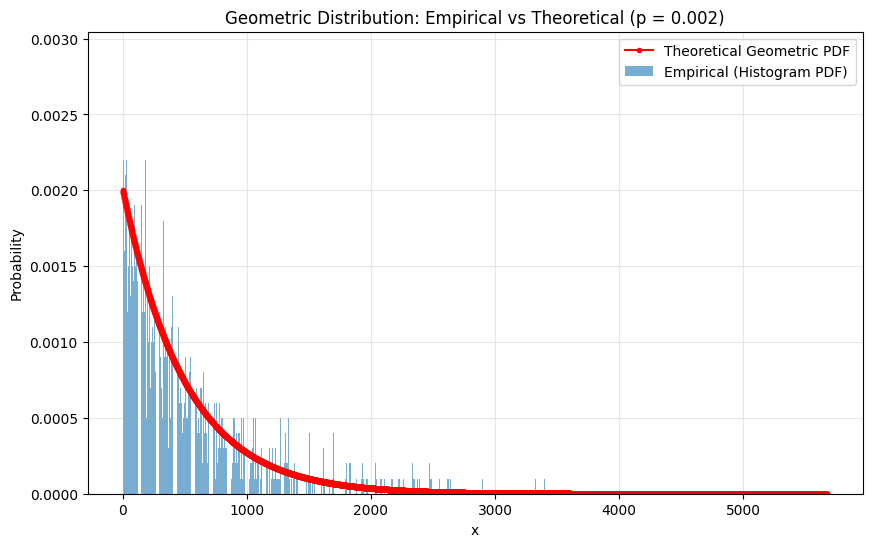

Chi-square statistic: 46.586187037920716
Chi-square p-value: 0.6111663260385857
Runs test Z: 0.4525990260272652
Above/below p-value: 0.6508375002402667


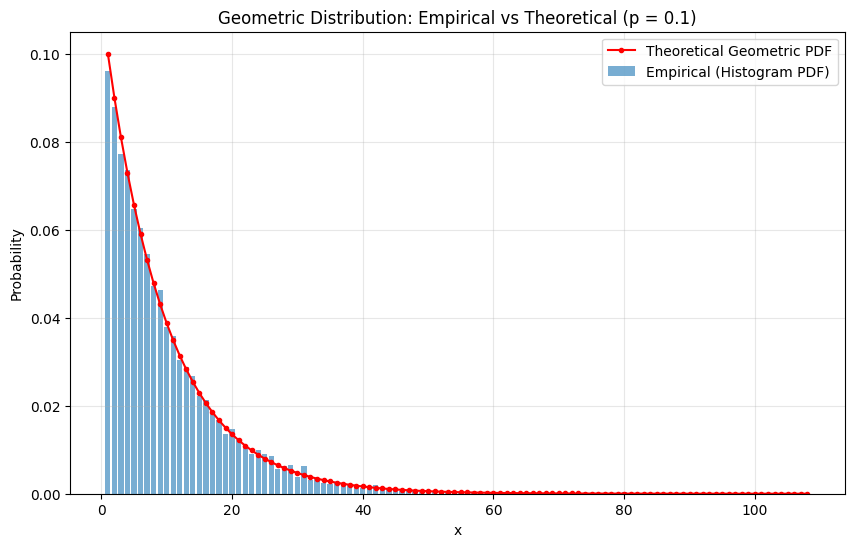

Chi-square statistic: 20.17089515749893
Chi-square p-value: 0.2655817547572496
Runs test Z: 0.41282750975669846
Above/below p-value: 0.679732994646891


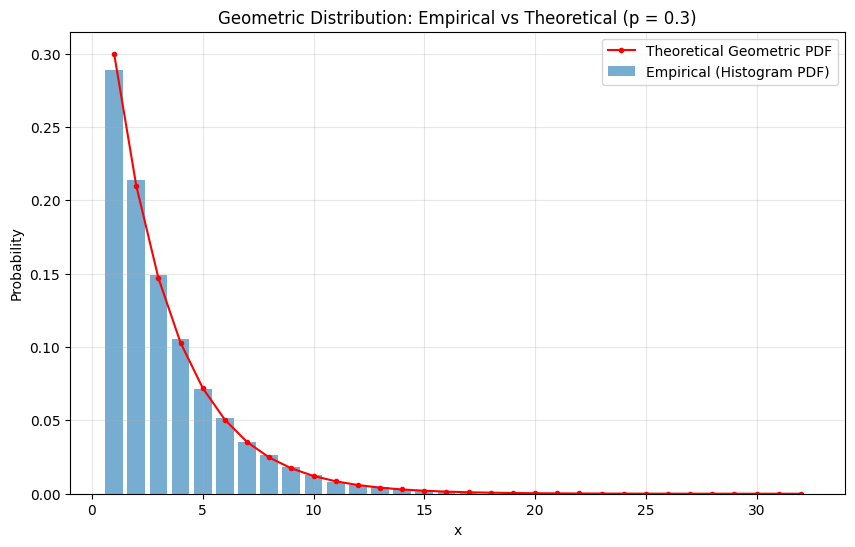

Chi-square statistic: 10.95211909367488
Chi-square p-value: 0.2790052223365163
Runs test Z: 0.8633466503143519
Above/below p-value: 0.38794690237893914


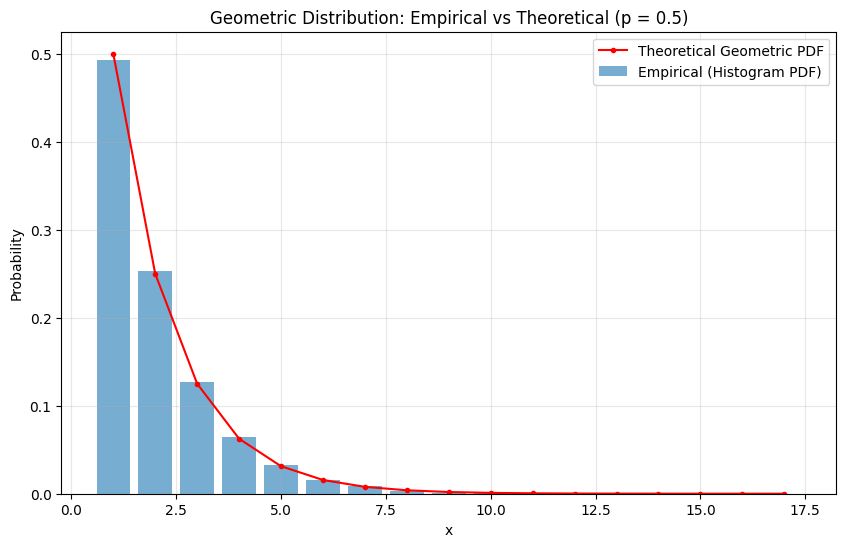

Chi-square statistic: 13.094838319728296
Chi-square p-value: 0.041554385418533846
Runs test Z: nan
Above/below p-value: nan


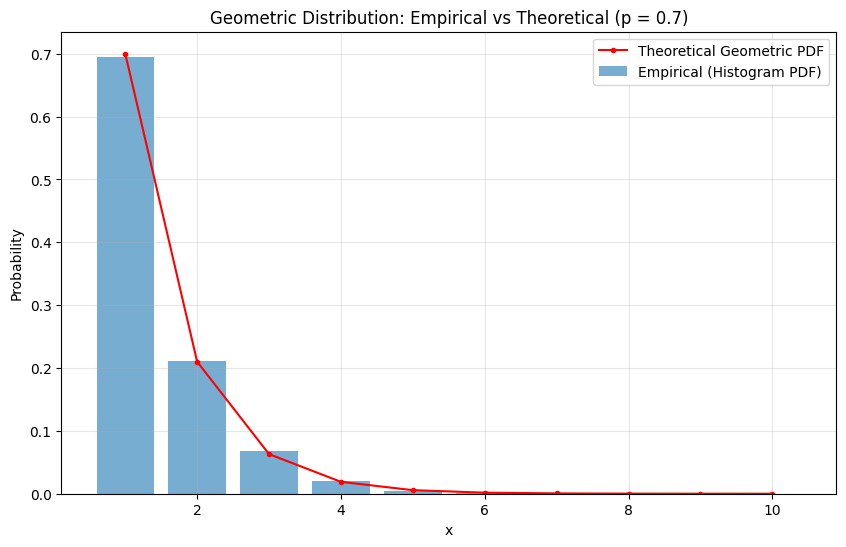

Chi-square statistic: 4.669533960188073
Chi-square p-value: 0.19765763629787836
Runs test Z: nan
Above/below p-value: nan


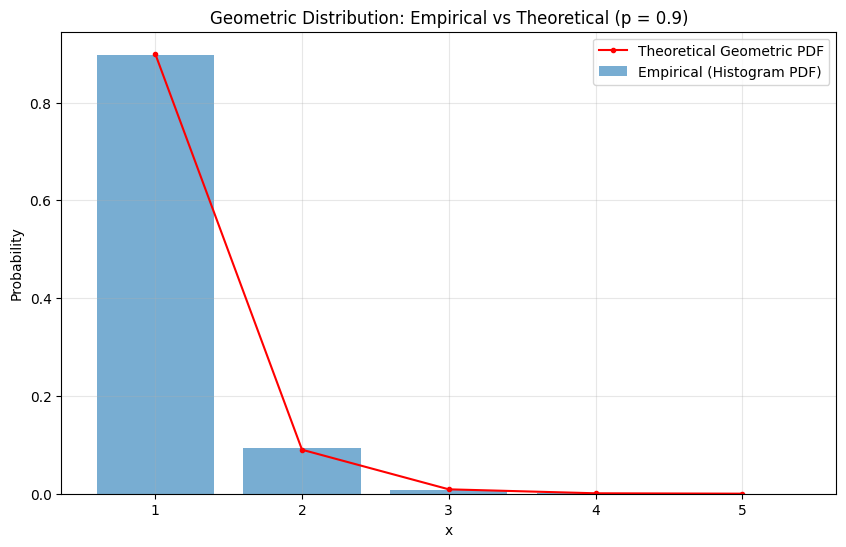

In [483]:
p = [0.002,0.1,0.3,0.5,0.7,0.9]

for element in p: 
    np.random.seed(42)
    U = np.random.rand(n)
    geometric_sample = (np.floor(np.log(U)/np.log(1-element))).astype(int) + 1

    max_x = geometric_sample.max()
    x_vals = np.arange(1, max_x + 1)   

    obs_counts = np.bincount(geometric_sample, minlength=max_x+1)[1:]
    hist_pdf = obs_counts / n


    theoretical_pdf = element * (1 - element) ** (x_vals - 1)
    exp_counts = theoretical_pdf * n
  
    mask = exp_counts >= 5
    obs = obs_counts[mask]
    exp = exp_counts[mask]

  
    exp = exp * (obs.sum() / exp.sum())
    chi_stat, p_value = chisquare(f_obs=obs, f_exp=exp)

    print("Chi-square statistic:", chi_stat)
    print("Chi-square p-value:", p_value)



    z_stat, p_value = runstest_1samp(geometric_sample, cutoff="median")

    print("Runs test Z:", z_stat)
    print("Above/below p-value:", p_value)

    plt.figure(figsize=(10, 6))
    plt.bar(x_vals, hist_pdf, alpha=0.6, label="Empirical (Histogram PDF)")
    plt.plot(x_vals, theoretical_pdf, 'r-', marker='o', markersize=3,
         label="Theoretical Geometric PDF")

    plt.title(f"Geometric Distribution: Empirical vs Theoretical (p = {element})")
    plt.xlabel("x")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()
    
    
    